# Advanced: Building a Production RAG Chatbot with LangGraph
## Hybrid Retrieval, Streaming, and Persistent Memory

### Learning Objectives
By the end of this notebook, you'll understand:
1. **LangGraph Basics** - Stateful multi-step agent graphs
2. **Hybrid Retrieval** - Combining BM25 + embeddings with Reciprocal Rank Fusion
3. **Streaming Responses** - Token-by-token output for real-time UIs
4. **Persistent Memory** - Multi-turn conversations across sessions
5. **Production Patterns** - Building scalable, deployable systems

## What We're Building

A complete RAG chatbot that:
- 🔍 **Retrieves** relevant docs using both keyword (BM25) and semantic (embeddings) search
- 🧠 **Remembers** the full conversation history
- 💬 **Streams** responses token-by-token
- 💾 **Persists** state across sessions

### Architecture
```
User Query
    ↓
[Retrieve] → BM25 + FAISS → Merged results (RRF)
    ↓
[Generate] → LLM with context + history → Stream tokens
    ↓
Response saved in checkpointer → Available for next turn
```

## Setup: Dependencies and API Keys

In [1]:
# Install required packages
%pip install -qU langgraph langchain langchain-openai langchain-community faiss-cpu rank_bm25 python-dotenv tiktoken

print("✓ Dependencies installed")

Note: you may need to restart the kernel to use updated packages.
✓ Dependencies installed


In [2]:
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv, find_dotenv
import os

# Load API keys from .env file
load_dotenv(find_dotenv())

# Verify key is loaded
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY not found in .env file")

print("✓ API keys loaded")

✓ API keys loaded


In [3]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# streaming=True enables token-level streaming
llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0,
    streaming=True  # Critical for token streaming
)

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

print(f"✓ LLM: {llm.model_name}")
print(f"✓ Embeddings: text-embedding-3-small (1536 dimensions)")

✓ LLM: gpt-4o
✓ Embeddings: text-embedding-3-small (1536 dimensions)


## Step 1: Create the Knowledge Base

We'll create sample documents about LangChain, LangGraph, and RAG.  
In production, you'd load PDFs, web pages, or database records.

In [4]:
from langchain_core.documents import Document

# Sample knowledge base
raw_texts = [
    # LangChain
    """LangChain is an open-source framework for building applications powered by large language models (LLMs). 
    It provides composable building blocks — prompts, chains, agents, tools, memory, and retrievers — 
    that developers can assemble to create complex AI applications. LangChain supports integrations with 
    over 60 LLM providers including OpenAI, Anthropic, and Cohere.""",

    """LangChain Expression Language (LCEL) is the recommended way to compose LangChain components. 
    It uses the pipe operator (|) to chain Runnables together: prompt | llm | output_parser. 
    LCEL supports streaming, async, batch, and parallel execution out of the box, 
    and provides an elegant way to build both simple chains and complex agent workflows.""",

    # LangGraph
    """LangGraph is a library for building stateful, multi-step agentic applications using a graph abstraction. 
    Unlike a simple chain, LangGraph represents your application as a directed graph where nodes are 
    functions (or LLM calls) and edges define the flow of data. It supports cycles, branching, 
    human-in-the-loop, and persistent state — making it ideal for complex agent architectures.""",

    """LangGraph StateGraph is the core primitive in LangGraph. You define a TypedDict as the graph state, 
    add nodes (Python functions), connect them with edges, and compile the graph. The state is passed 
    between nodes and accumulated using reducer functions. The special `add_messages` reducer appends 
    messages to the conversation history without overwriting them.""",

    """LangGraph supports three streaming modes: 'values' streams the full graph state after each step, 
    'updates' streams only the node output deltas, and 'messages' streams individual LLM token chunks 
    for real-time token-level output. You can combine modes by passing a list: stream_mode=['updates', 'messages'].""",

    # RAG
    """Retrieval-Augmented Generation (RAG) is a technique that grounds LLM responses in external knowledge. 
    Instead of relying solely on the model's parametric memory, RAG retrieves relevant documents at 
    query time and injects them into the prompt as context. This reduces hallucinations and lets the 
    model answer questions about private or up-to-date information.""",

    """Dense retrieval uses neural embedding models to encode documents and queries into vector space. 
    Semantic similarity is measured with cosine similarity or dot product. FAISS (Facebook AI Similarity Search) 
    is a popular library for efficient approximate nearest-neighbor search over millions of embeddings. 
    OpenAI's text-embedding-3-small model produces 1536-dimensional vectors at low cost.""",

    """BM25 (Best Match 25) is a classical sparse retrieval algorithm based on TF-IDF with document 
    length normalization. It excels at exact keyword matching and handles out-of-vocabulary terms 
    that embedding models might miss. BM25 is fast, requires no GPU, and needs no training data — 
    making it a strong baseline for any retrieval system.""",

    # Hybrid Retrieval
    """Hybrid retrieval combines sparse retrieval (BM25) and dense retrieval (embeddings) to get the 
    best of both worlds. BM25 handles exact keyword matches well; dense retrieval captures semantic 
    similarity. The EnsembleRetriever in LangChain merges results using Reciprocal Rank Fusion (RRF), 
    a rank-aggregation method that is robust to score distribution differences between retrievers.""",

    """Reciprocal Rank Fusion (RRF) scores each document as the sum of 1/(k + rank_i) across retrievers, 
    where k=60 by default. Documents appearing at the top of multiple retriever result lists receive 
    the highest combined score. RRF is parameter-light and outperforms linear score interpolation 
    in most benchmarks without requiring score normalization.""",
]

documents = [Document(page_content=text.strip()) for text in raw_texts]

print(f"✓ Created {len(documents)} documents")
print(f"\nExample document:")
print(f"{documents[0].page_content[:150]}...")

✓ Created 10 documents

Example document:
LangChain is an open-source framework for building applications powered by large language models (LLMs). 
    It provides composable building blocks —...


## Step 2: Building Hybrid Retrieval

### Why Hybrid?
- **BM25** (keyword): Fast, handles exact matches ("LangGraph", "tokens")
- **FAISS** (semantic): Handles synonyms ("LLM" ≈ "language model")
- **Hybrid**: Get both! Use **Reciprocal Rank Fusion** to merge results

### How RRF Works:
```
BM25 ranking: [Doc A (rank 1), Doc B (rank 2), Doc C (rank 3)]
FAISS ranking: [Doc B (rank 1), Doc A (rank 2), Doc D (rank 3)]

RRF score: Doc A = 1/(60+1) + 1/(60+2) = 0.0328
           Doc B = 1/(60+2) + 1/(60+1) = 0.0328
           Doc C = 1/(60+3) = 0.0160
           Doc D = 1/(60+3) = 0.0160

Final ranking: A ≈ B > C ≈ D
```

In [5]:
from langchain_community.retrievers import BM25Retriever

# BM25 — keyword-based retrieval (no embeddings needed)
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 4  # Return top-4 documents

# Quick test
test_query = "streaming tokens"
bm25_results = bm25_retriever.invoke(test_query)

print(f"BM25 returned {len(bm25_results)} documents for: '{test_query}'")
print(f"\nTop result:")
print(bm25_results[0].page_content[:150] + "...")

BM25 returned 4 documents for: 'streaming tokens'

Top result:
LangGraph supports three streaming modes: 'values' streams the full graph state after each step, 
    'updates' streams only the node output deltas, a...


In [6]:
from langchain_community.vectorstores import FAISS

# Dense retriever using FAISS (requires embedding all documents)
print("Building FAISS index (embedding documents)...")
vectorstore = FAISS.from_documents(documents, embeddings)
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

# Quick test
dense_results = dense_retriever.invoke(test_query)

print(f"✓ FAISS returned {len(dense_results)} documents")
print(f"\nTop result:")
print(dense_results[0].page_content[:150] + "...")

Building FAISS index (embedding documents)...
✓ FAISS returned 4 documents

Top result:
LangGraph supports three streaming modes: 'values' streams the full graph state after each step, 
    'updates' streams only the node output deltas, a...


In [7]:
from langchain_core.retrievers import BaseRetriever
from pydantic import Field
from typing import List

class EnsembleRetriever(BaseRetriever):
    """Hybrid retriever combining BM25 and dense search with RRF."""
    
    retrievers: List[BaseRetriever] = Field(..., description="List of retrievers to combine")
    weights: List[float] = Field(default=None, description="Weights for each retriever")
    k: int = Field(default=60, description="RRF parameter")
    
    def __init__(self, retrievers: List[BaseRetriever], weights: List[float] = None, k: int = 60, **kwargs):
        # Normalize weights
        if weights is None:
            weights = [1.0 / len(retrievers)] * len(retrievers)
        else:
            total = sum(weights)
            weights = [w / total for w in weights]
        
        super().__init__(retrievers=retrievers, weights=weights, k=k, **kwargs)
    
    def _get_relevant_documents(self, query: str) -> List[Document]:
        """Use RRF to merge results from multiple retrievers."""
        docs_dict = {}
        
        # Get results from each retriever
        for retriever, weight in zip(self.retrievers, self.weights):
            docs = retriever.invoke(query)
            
            # Score each document using RRF
            for rank, doc in enumerate(docs):
                doc_str = doc.page_content
                if doc_str not in docs_dict:
                    docs_dict[doc_str] = {"doc": doc, "score": 0}
                
                # RRF formula: weight * 1/(k + rank)
                rrf_score = 1 / (self.k + rank + 1)
                docs_dict[doc_str]["score"] += weight * rrf_score
        
        # Sort by combined score
        sorted_docs = sorted(
            docs_dict.items(), 
            key=lambda x: x[1]["score"], 
            reverse=True
        )
        
        return [item[1]["doc"] for item in sorted_docs]
    
    async def _aget_relevant_documents(self, query: str) -> List[Document]:
        """Async version (required by base class)."""
        return self._get_relevant_documents(query)

# Create hybrid retriever: 40% BM25 + 60% dense
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.4, 0.6],
    k=60  # RRF parameter
)

# Test
hybrid_results = hybrid_retriever.invoke(test_query)

print(f"✓ Hybrid retriever returned {len(hybrid_results)} documents")
print(f"\nTop result:")
print(hybrid_results[0].page_content[:150] + "...")

✓ Hybrid retriever returned 6 documents

Top result:
LangGraph supports three streaming modes: 'values' streams the full graph state after each step, 
    'updates' streams only the node output deltas, a...


## Step 3: Define the Graph State

In LangGraph, the **state** is what flows between nodes. Our state has:
- `messages`: Full conversation history (accumulates with `add_messages` reducer)
- `context`: Retrieved document text injected into the prompt

In [8]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    """State passed between graph nodes."""
    # add_messages: new messages are appended to the list, not replaced
    messages: Annotated[list[BaseMessage], add_messages]
    # context: retrieved documents as a single string
    context: str

print("✓ ChatState defined")

✓ ChatState defined


## Step 4: Define Graph Nodes

### Node 1: Retrieve
Extract the latest user message and retrieve relevant documents.

### Node 2: Generate
Call the LLM with conversation history + retrieved context.

In [9]:
# ── Node 1: Retrieve ──────────────────────────────────────────────────────────
def retrieve(state: ChatState) -> dict:
    """Extract the latest user query and retrieve relevant documents."""
    # Find the most recent HumanMessage
    last_human = next(
        (m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)),
        None,
    )
    
    query = last_human.content if last_human else ""
    
    # Retrieve documents
    docs = hybrid_retriever.invoke(query)
    
    # Format as a single context string
    context = "\n\n".join(
        f"[Document {i+1}]\n{doc.page_content}" 
        for i, doc in enumerate(docs)
    )
    
    return {"context": context}

print("✓ Retrieve node defined")

✓ Retrieve node defined


In [10]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# ── Node 2: Generate ──────────────────────────────────────────────────────────
SYSTEM_PROMPT = """You are a knowledgeable AI assistant specializing in LangChain, LangGraph, and RAG systems.
Use the retrieved context below to answer the user's question accurately.
If the context does not contain enough information, say so and answer from your own knowledge.

Retrieved context:
{context}"""

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    MessagesPlaceholder(variable_name="messages"),
])

generate_chain = prompt | llm

def generate(state: ChatState) -> dict:
    """Call the LLM with conversation history and retrieved context."""
    response = generate_chain.invoke({
        "context": state["context"],
        "messages": state["messages"],
    })
    return {"messages": [response]}

print("✓ Generate node defined")

✓ Generate node defined


## Step 5: Build and Compile the Graph

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# Build the graph
builder = StateGraph(ChatState)

# Add nodes
builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)

# Add edges: START → retrieve → generate → END
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

# Compile with MemorySaver for persistent state
# Each thread_id has its own state that persists across invocations
memory = MemorySaver()
chatbot = builder.compile(checkpointer=memory)

print("✓ Graph compiled successfully")

✓ Graph compiled successfully


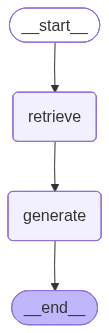

In [12]:
# Visualize the graph
try:
    from IPython.display import Image, display
    display(Image(chatbot.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization not available (install graphviz)")
    print("Mermaid source:")
    print(chatbot.get_graph().draw_mermaid())

## Step 6: Single-Turn Chat (Without Streaming)

In [13]:
def chat(question: str, thread_id: str = "default") -> str:
    """Send a question and get a blocking response."""
    config = {"configurable": {"thread_id": thread_id}}
    initial_state = {
        "messages": [HumanMessage(content=question)],
        "context": "",
    }
    
    result = chatbot.invoke(initial_state, config=config)
    return result["messages"][-1].content

# First turn
answer1 = chat(
    "What is LangGraph and how does it differ from a simple LangChain chain?",
    thread_id="demo-1"
)
print("Q: What is LangGraph and how does it differ from a simple LangChain chain?")
print(f"A: {answer1}\n")

Q: What is LangGraph and how does it differ from a simple LangChain chain?
A: LangGraph is a library designed for building stateful, multi-step agentic applications using a graph abstraction. Unlike a simple LangChain chain, which represents a linear sequence of operations, LangGraph represents your application as a directed graph. In this graph, nodes are functions (or LLM calls), and edges define the flow of data. This allows LangGraph to support more complex structures such as cycles, branching, human-in-the-loop interactions, and persistent state management. These features make LangGraph particularly suitable for complex agent architectures, whereas a simple LangChain chain is more suited for straightforward, linear workflows.



In [14]:
# Second turn with same thread_id — chatbot remembers the previous turn!
answer2 = chat(
    "And what streaming modes does it support?",
    thread_id="demo-1"
)
print("Q: And what streaming modes does it support?")
print(f"A: {answer2}")

Q: And what streaming modes does it support?
A: LangGraph supports three streaming modes:

1. **'values'**: Streams the full graph state after each step.
2. **'updates'**: Streams only the node output deltas.
3. **'messages'**: Streams individual LLM token chunks for real-time token-level output.

You can also combine these modes by passing a list, such as `stream_mode=['updates', 'messages']`.


## Step 7: Streaming Responses (Token by Token)

Use `stream()` with `stream_mode="messages"` to get tokens as they're generated.

In [15]:
from langchain_core.messages import AIMessageChunk

def chat_stream(question: str, thread_id: str = "stream-demo") -> str:
    """Stream response token by token."""
    config = {"configurable": {"thread_id": thread_id}}
    initial_state = {
        "messages": [HumanMessage(content=question)],
        "context": "",
    }

    print(f"Q: {question}")
    print("A: ", end="", flush=True)

    full_response = ""
    for chunk, metadata in chatbot.stream(
        initial_state,
        config=config,
        stream_mode="messages",
    ):
        # Only print tokens from the generate node
        if (
            isinstance(chunk, AIMessageChunk)
            and metadata.get("langgraph_node") == "generate"
            and chunk.content
        ):
            print(chunk.content, end="", flush=True)
            full_response += chunk.content

    print()  # newline
    return full_response

# Test streaming
_ = chat_stream(
    "Explain how BM25 works and why we combine it with embedding-based retrieval.",
    thread_id="stream-1"
)

Q: Explain how BM25 works and why we combine it with embedding-based retrieval.
A: BM25 (Best Match 25) is a classical sparse retrieval algorithm that builds on the TF-IDF (Term Frequency-Inverse Document Frequency) model with an added component for document length normalization. It excels at exact keyword matching, making it particularly effective for handling out-of-vocabulary terms that embedding models might miss. BM25 is known for its speed, does not require a GPU, and does not need any training data, which makes it a strong baseline for any retrieval system.

However, BM25's reliance on exact keyword matching can be a limitation when dealing with queries that require understanding of semantic similarity rather than just keyword overlap. This is where embedding-based retrieval comes into play. Dense retrieval methods use neural embedding models to encode documents and queries into a vector space, allowing for the measurement of semantic similarity using techniques like cosine simi

In [16]:
_ = chat_stream(
    "What is Reciprocal Rank Fusion and how does EnsembleRetriever use it?",
    thread_id="stream-2"
)

Q: What is Reciprocal Rank Fusion and how does EnsembleRetriever use it?
A: Reciprocal Rank Fusion (RRF) is a rank-aggregation method used to combine the results from multiple retrievers. It scores each document by summing the values of 1/(k + rank_i) across different retrievers, where k is typically set to 60 by default. This method gives higher scores to documents that appear at the top of multiple retriever result lists, making it robust to differences in score distributions between retrievers. RRF is parameter-light and generally outperforms linear score interpolation in benchmarks without needing score normalization.

The EnsembleRetriever in LangChain uses RRF to merge results from different retrieval methods, such as sparse retrieval (e.g., BM25) and dense retrieval (e.g., embeddings). By doing so, it leverages the strengths of both retrieval types: BM25's ability to handle exact keyword matches and dense retrieval's capability to capture semantic similarity. This combination ai

## Step 8: Multi-Turn Conversation

Because of the checkpointer, each call with the same `thread_id` resumes from where it left off.

In [17]:
THREAD = "tutorial-session"
DIVIDER = "-" * 70

questions = [
    "What is RAG and why is it useful?",
    "How does the retrieval step work in a RAG pipeline?",
    "What are the advantages of adding BM25 to semantic search?",
    "Can you summarize what we discussed in three bullet points?",
]

for q in questions:
    print(DIVIDER)
    response = chat_stream(q, thread_id=THREAD)
    print()

----------------------------------------------------------------------
Q: What is RAG and why is it useful?
A: Retrieval-Augmented Generation (RAG) is a technique that enhances the responses of large language models (LLMs) by grounding them in external knowledge. Instead of relying solely on the model's internal memory, RAG retrieves relevant documents at the time of the query and incorporates them into the prompt as context. This approach is useful because it reduces the likelihood of hallucinations—where the model generates incorrect or fabricated information—and allows the model to answer questions about private or up-to-date information that may not be included in its training data.

----------------------------------------------------------------------
Q: How does the retrieval step work in a RAG pipeline?
A: In a Retrieval-Augmented Generation (RAG) pipeline, the retrieval step involves fetching relevant documents or pieces of information from an external knowledge base to provid

## Step 9: Inspect Conversation History

With the checkpointer, you can retrieve the entire state for any thread.

In [18]:
# Get the current state
config = {"configurable": {"thread_id": THREAD}}
state_snapshot = chatbot.get_state(config)

messages = state_snapshot.values["messages"]
print(f"Conversation history: {len(messages)} messages\n")
print("="*70)

for i, msg in enumerate(messages, 1):
    role = "🧑 User" if isinstance(msg, HumanMessage) else "🤖 Assistant"
    content = msg.content[:120] + "..." if len(msg.content) > 120 else msg.content
    print(f"\n{i}. {role}")
    print(f"   {content}")

Conversation history: 8 messages


1. 🧑 User
   What is RAG and why is it useful?

2. 🤖 Assistant
   Retrieval-Augmented Generation (RAG) is a technique that enhances the responses of large language models (LLMs) by groun...

3. 🧑 User
   How does the retrieval step work in a RAG pipeline?

4. 🤖 Assistant
   In a Retrieval-Augmented Generation (RAG) pipeline, the retrieval step involves fetching relevant documents or pieces of...

5. 🧑 User
   What are the advantages of adding BM25 to semantic search?

6. 🤖 Assistant
   Adding BM25 to semantic search provides several advantages:

1. **Exact Keyword Matching**: BM25 excels at handling exac...

7. 🧑 User
   Can you summarize what we discussed in three bullet points?

8. 🤖 Assistant
   - **Retrieval-Augmented Generation (RAG)**: RAG enhances LLM responses by retrieving relevant external documents at quer...


## Step 10: Compare Retrieval Methods

See how BM25, FAISS, and Hybrid retrieval each handle the same query.

In [19]:
def compare_retrievers(query: str, k: int = 3):
    """Compare results from different retrieval methods."""
    bm25_retriever.k = k
    dense_r = vectorstore.as_retriever(search_kwargs={"k": k})
    hybrid_r = EnsembleRetriever(
        retrievers=[bm25_retriever, dense_r],
        weights=[0.4, 0.6]
    )

    print(f"Query: '{query}'\n")
    print("="*70)

    for label, retriever in [
        ("BM25 (Keyword)", bm25_retriever),
        ("FAISS (Semantic)", dense_r),
        ("Hybrid (BM25 + FAISS)", hybrid_r)
    ]:
        results = retriever.invoke(query)
        print(f"\n{label}:")
        for i, doc in enumerate(results, 1):
            snippet = doc.page_content[:100].replace("\n", " ")
            print(f"  {i}. {snippet}...")

# Test different queries
compare_retrievers("LLM streaming tokens")
print("\n")
compare_retrievers("keyword exact match TF-IDF")

Query: 'LLM streaming tokens'


BM25 (Keyword):
  1. LangGraph supports three streaming modes: 'values' streams the full graph state after each step,    ...
  2. LangChain is an open-source framework for building applications powered by large language models (LL...
  3. Retrieval-Augmented Generation (RAG) is a technique that grounds LLM responses in external knowledge...

FAISS (Semantic):
  1. LangGraph supports three streaming modes: 'values' streams the full graph state after each step,    ...
  2. LangChain Expression Language (LCEL) is the recommended way to compose LangChain components.      It...
  3. LangChain is an open-source framework for building applications powered by large language models (LL...

Hybrid (BM25 + FAISS):
  1. LangGraph supports three streaming modes: 'values' streams the full graph state after each step,    ...
  2. LangChain is an open-source framework for building applications powered by large language models (LL...
  3. LangChain Expression Language (L

## Key Takeaways

### Architecture
- **Retrieve**: Hybrid (BM25 + FAISS) with Reciprocal Rank Fusion
- **Generate**: LLM with conversation history + retrieved context
- **Memory**: MemorySaver checkpointer for persistent multi-turn state
- **Streaming**: Token-by-token output via `stream_mode="messages"`

### Why Each Component Matters
| Component | Benefit |
|-----------|----------|
| BM25 | Exact keyword matches ("LangGraph", "streaming") |
| FAISS | Semantic similarity ("LLM" ≈ "language model") |
| RRF | Robust rank aggregation without score tuning |
| Streaming | Real-time UI feedback |
| Checkpointer | Resume conversations across sessions |

### Production Extensions
- **Conditional routing**: Skip retrieval for greetings
- **Query rewriting**: Rephrase queries before retrieval
- **Re-ranking**: Cross-encoder between retrieval and generation
- **Persistence**: Use PostgresSaver instead of MemorySaver
- **Async streaming**: Expose via FastAPI StreamingResponse